## Эксперименты
**Обучение на сырых данных**
- Score: $0.7908$

**Добавление фич с помощью `PCA`**
- Score: $0.7901$
- Effect: $-0.0007$
- Не используем

**Добавление суммы аггрегации `price` в данные**
- Score: $0.7922$
- Effect: $0.0014$
- Одни из самых важных фич связаны с суммарным количеством денег, потраченных пользователем 

**Добавление фич с помощью `KMeans`**
- Score: $0.7631$
- Effect: $+0.0023$

**Генерация фич с помощью ML**
- Score: $0.7615$
- Effect: $-0.0016$ (учитывая, что добавлена кластеризация)
- Не используем

**Исключение фич, показавших низкую значимость**
- Score: $0.7933$
- Effect: $+0.002$ (учитывая, что добавлена кластеризация)

In [1]:
from pathlib import Path
from typing import Optional, Dict, Any, List
from datetime import date, timedelta
import random
from copy import copy

import numpy as np
import polars as pl

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression

from cuml.manifold import UMAP

import lightgbm
import catboost

import warnings

warnings.filterwarnings("ignore")

SEED = 666
random.seed(SEED)
np.random.seed(SEED)

In [2]:
control_start_date = date(2024, 7, 1)
control_end_date = date(2024, 8, 1)
data_path = Path("predict-user-order/")

## Чтение данных

In [3]:
actions_history = pl.read_parquet(data_path / "actions_history")
search_history = pl.read_parquet(data_path / "search_history")
product_information = pl.read_csv(data_path / "product_information.csv")
action_types = pl.read_csv(data_path / "action_type_info.csv")
test_users = pl.read_csv(data_path / "test_users.csv")

In [4]:
action_types

action_type,action_type_id
str,i64
"""click""",1
"""favorite""",2
"""order""",3
"""search""",4
"""to_cart""",5
"""view""",6


Обнаружилось, что в `product_information` довольно много нулевых значений в ценах. Скорее всего, это пропуски

In [5]:
product_information.filter(pl.col("price") == 0)

product_id,name,brand,type,category_id,category_name,price,discount_price
i64,str,str,str,i64,str,f64,f64
1645519130,"""Швабра с отжимом и ведром Ridb…","""Ridberg Home""","""Швабра""",793,"""Швабры, ведра, лопаты""",0.0,0.0
1648642546,"""Святой Источник Светлячок Вода…","""Святой Источник""","""Вода""",228,"""Вода детская""",0.0,0.0
1649304886,"""LIMONI Антивозрастной крем для…","""LIMONI""","""Крем для ухода за кожей""",468,"""Для всех типов кожи""",0.0,0.0
1655110501,"""Кислородный очиститель BRANDFR…","""BRANDFREE""","""Пятновыводитель""",161,"""Пятновыводители""",0.0,0.0
1655302674,"""Набор для уборки GRASS: средст…","""Grass""","""Универсальное чистящее средств…",327,"""Для посуды""",0.0,0.0
…,…,…,…,…,…,…,…
1665110648,"""Салфетки бумажные 1 слоя 24 см…","""Gratias""","""Бумажные салфетки""",301,"""Салфетки бумажные""",0.0,0.0
1667861556,"""Зубная паста детская R.O.C.S. …","""R.O.C.S.""","""Зубная паста""",642,"""Зубные пасты и ополаскиватели""",0.0,0.0
1674778291,"""Доска разделочная 36x24x1,2см …","""BY""","""Разделочная доска""",202,"""Ножи и доски""",0.0,0.0


In [6]:
avg_cat_prices = (
    product_information.filter(pl.col("price") > 0)
    .group_by(pl.col("category_id"))
    .agg(
        pl.col("price").mean().alias("avg_price"),
        pl.col("discount_price").mean().alias("avg_discount_price"),
        pl.col("price").std().alias("std_price"),
        pl.col("discount_price").std().alias("std_discount_price"),
        pl.col("product_id").count().alias("n_products"),
    )
)
avg_cat_prices

category_id,avg_price,avg_discount_price,std_price,std_discount_price,n_products
i64,f64,f64,f64,f64,u32
789,376.5,245.666667,171.230546,111.550288,6
396,11718.492308,8222.107692,5205.40048,4685.298307,65
134,372.62963,280.938272,187.855027,133.802685,81
6,350.414894,328.861702,331.487764,317.627922,94
792,957.5,678.2,169.370239,231.342843,10
…,…,…,…,…,…
524,1062.273148,639.490741,1070.816678,568.034137,216
655,868.700503,493.402116,654.465543,322.207344,248
914,567.0,421.857143,323.28054,219.738606,14


не будем заменять эти нули на значения средних по категориям, так как дисперсия цен в категориях довольно высокая. Лучше добавим отдельные фичи со средними ценами по категориям

In [7]:
product_information = product_information.join(
    avg_cat_prices.select(
        "category_id", 
        pl.col("avg_price").alias("category_avg_price"), 
        pl.col("avg_discount_price").alias("category_avg_discount_price")
    ), 
    on="category_id", 
    how="left"
)

In [8]:
product_information

product_id,name,brand,type,category_id,category_name,price,discount_price,category_avg_price,category_avg_discount_price
i64,str,str,str,i64,str,f64,f64,f64,f64
26176363,"""Развивающие тесты (3-4 года) (…","""Machaon""","""Печатная книга: Развитие детей""",780,"""Книги""",380.0,274.0,1191.846573,747.762077
29898500,"""Mexx Туалетная вода Ice Touch …","""Mexx""","""Туалетная вода""",117,"""Мужская""",2645.0,1859.0,2894.742857,1875.761905
33967827,"""64 ГБ USB Флеш-накопитель USB …","""SmartBuy""","""USB-флеш-накопитель""",178,"""Флешки и CD-R""",1690.0,469.0,2423.477874,1017.070061
135938830,"""Чай листовой чёрный Ahmad Tea …","""Ahmad Tea""","""Чай листовой""",465,"""Чай листовой""",319.0,244.0,936.382409,474.432122
137920686,"""Seagate 4 ТБ Внешний жесткий д…","""Seagate""","""Внешний жесткий диск""",615,"""Внешние жесткие диски""",28590.0,9539.0,11641.225317,7135.423678
…,…,…,…,…,…,…,…,…,…
1665110648,"""Салфетки бумажные 1 слоя 24 см…","""Gratias""","""Бумажные салфетки""",301,"""Салфетки бумажные""",0.0,0.0,468.232507,262.299173
1667861556,"""Зубная паста детская R.O.C.S. …","""R.O.C.S.""","""Зубная паста""",642,"""Зубные пасты и ополаскиватели""",0.0,0.0,833.995172,525.196637
1674778291,"""Доска разделочная 36x24x1,2см …","""BY""","""Разделочная доска""",202,"""Ножи и доски""",0.0,0.0,2848.674986,1341.955688


## Подготовка данных

In [9]:
train_df = (
    actions_history.filter(
        pl.col("timestamp") < control_end_date,
        pl.col("timestamp") >= control_start_date,
    )
    .select("user_id", (pl.col("action_type_id") == 3).cast(pl.Int8).alias("target"))
    .group_by("user_id")
    .agg(pl.col("target").max())
)

train_df["target"].value_counts()

target,count
i8,u32
1,647575
0,1227381


In [10]:
product_information

product_id,name,brand,type,category_id,category_name,price,discount_price,category_avg_price,category_avg_discount_price
i64,str,str,str,i64,str,f64,f64,f64,f64
26176363,"""Развивающие тесты (3-4 года) (…","""Machaon""","""Печатная книга: Развитие детей""",780,"""Книги""",380.0,274.0,1191.846573,747.762077
29898500,"""Mexx Туалетная вода Ice Touch …","""Mexx""","""Туалетная вода""",117,"""Мужская""",2645.0,1859.0,2894.742857,1875.761905
33967827,"""64 ГБ USB Флеш-накопитель USB …","""SmartBuy""","""USB-флеш-накопитель""",178,"""Флешки и CD-R""",1690.0,469.0,2423.477874,1017.070061
135938830,"""Чай листовой чёрный Ahmad Tea …","""Ahmad Tea""","""Чай листовой""",465,"""Чай листовой""",319.0,244.0,936.382409,474.432122
137920686,"""Seagate 4 ТБ Внешний жесткий д…","""Seagate""","""Внешний жесткий диск""",615,"""Внешние жесткие диски""",28590.0,9539.0,11641.225317,7135.423678
…,…,…,…,…,…,…,…,…,…
1665110648,"""Салфетки бумажные 1 слоя 24 см…","""Gratias""","""Бумажные салфетки""",301,"""Салфетки бумажные""",0.0,0.0,468.232507,262.299173
1667861556,"""Зубная паста детская R.O.C.S. …","""R.O.C.S.""","""Зубная паста""",642,"""Зубные пасты и ополаскиватели""",0.0,0.0,833.995172,525.196637
1674778291,"""Доска разделочная 36x24x1,2см …","""BY""","""Разделочная доска""",202,"""Ножи и доски""",0.0,0.0,2848.674986,1341.955688


In [11]:
def get_search_aggregation(
    action_id: int,
    action_name: str,
    cutoff_date: date,
    history_depth_months: int,
) -> pl.DataFrame:
    conds = [
        pl.col("action_type_id") == action_id,
        pl.col("timestamp") < cutoff_date,
        pl.col("timestamp") >= cutoff_date - timedelta(days=30 * history_depth_months),
    ]

    transforms = [
        pl.col("action_type_id").count().alias(f"{action_name}_count"),
        pl.col("widget_name_id")
        .mode()
        .first()
        .alias(f"{action_name}_most_common_widget"),
        pl.col("widget_name_id")
        .n_unique()
        .alias(f"{action_name}_count_distinct_widgets"),
        (cutoff_date - pl.col("timestamp").max())
        .dt.total_days()
        .alias(f"{action_name}_last_days"),
        (cutoff_date - pl.col("timestamp").min())
        .dt.total_days()
        .alias(f"{action_name}_first_days"),
    ]

    agg = search_history.filter(*conds).group_by("user_id").agg(*transforms)

    return agg


def get_action_aggregation(
    action_id: int,
    action_name: str,
    cutoff_date: date,
    history_depth_months: int,
) -> pl.DataFrame:
    conds = [
        pl.col("action_type_id") == action_id,
        pl.col("timestamp") < cutoff_date,
        pl.col("timestamp") >= cutoff_date - timedelta(days=30 * history_depth_months),
    ]
    columns = [
        "price",
        "discount_price",
        "category_avg_price",
        "category_avg_discount_price",
    ]
    transforms = [
        transform
        for col_name in columns
        for transform in [
            pl.col(col_name).mean().alias(f"{action_name}_mean_{col_name}"),
            pl.col(col_name).std().alias(f"{action_name}_std_{col_name}"),
            pl.col(col_name).min().alias(f"{action_name}_min_{col_name}"),
            pl.col(col_name).max().alias(f"{action_name}_max_{col_name}"),
            pl.col(col_name).sum().alias(f"{action_name}_sum_{col_name}"),
        ]
    ]
    transforms.extend(
        [
            pl.col("product_id").count().alias(f"{action_name}_count"),
            (cutoff_date - pl.col("timestamp").max())
            .dt.total_days()
            .alias(f"{action_name}_last_days"),
            (cutoff_date - pl.col("timestamp").min())
            .dt.total_days()
            .alias(f"{action_name}_first_days"),
            (pl.col("price") - pl.col("discount_price"))
            .mean()
            .alias(f"{action_name}_mean_discount_diff"),
            (pl.col("price") - pl.col("discount_price"))
            .std()
            .alias(f"{action_name}_std_discount_diff"),
            (pl.col("price") - pl.col("discount_price"))
            .min()
            .alias(f"{action_name}_min_discount_diff"),
            (pl.col("price") - pl.col("discount_price"))
            .max()
            .alias(f"{action_name}_max_discount_diff"),
            pl.col("category_id")
            .mode()
            .first()
            .alias(f"{action_name}_most_common_category"),
            pl.col("category_id")
            .n_unique()
            .alias(f"{action_name}_count_distinct_categories"),
        ]
    )

    agg = (
        actions_history.filter(*conds)
        .join(
            product_information.select(
                "product_id",
                "category_id",
                "price",
                "discount_price",
                "category_avg_price",
                "category_avg_discount_price",
            ),
            on="product_id",
            how="left",
        )
        .group_by("user_id")
        .agg(*transforms)
    )

    return agg


def get_aggregation_features(
    df: pl.DataFrame,
    cutoff_date: date,
    history_depth_months: float = 8,
) -> pl.DataFrame:
    aggs = []
    for action_name, action_id in list(action_types.iter_rows())[:-1]:
        if action_name == "search":
            agg = get_search_aggregation(
                action_id, action_name, cutoff_date, history_depth_months
            )
        else:
            agg = get_action_aggregation(
                action_id, action_name, cutoff_date, history_depth_months
            )

        aggs.append(agg)

    for agg in aggs:
        df = df.join(agg, on="user_id", how="left")

    return df


In [12]:
train_df = get_aggregation_features(
    train_df, control_start_date, history_depth_months=8
)

In [13]:
train_df.filter(*[pl.col(col_name).is_null() for col_name in train_df.columns[2:]])

user_id,target,click_mean_price,click_std_price,click_min_price,click_max_price,click_sum_price,click_mean_discount_price,click_std_discount_price,click_min_discount_price,click_max_discount_price,click_sum_discount_price,click_mean_category_avg_price,click_std_category_avg_price,click_min_category_avg_price,click_max_category_avg_price,click_sum_category_avg_price,click_mean_category_avg_discount_price,click_std_category_avg_discount_price,click_min_category_avg_discount_price,click_max_category_avg_discount_price,click_sum_category_avg_discount_price,click_count,click_last_days,click_first_days,click_mean_discount_diff,click_std_discount_diff,click_min_discount_diff,click_max_discount_diff,click_most_common_category,click_count_distinct_categories,favorite_mean_price,favorite_std_price,favorite_min_price,favorite_max_price,favorite_sum_price,favorite_mean_discount_price,…,order_max_discount_diff,order_most_common_category,order_count_distinct_categories,search_count,search_most_common_widget,search_count_distinct_widgets,search_last_days,search_first_days,to_cart_mean_price,to_cart_std_price,to_cart_min_price,to_cart_max_price,to_cart_sum_price,to_cart_mean_discount_price,to_cart_std_discount_price,to_cart_min_discount_price,to_cart_max_discount_price,to_cart_sum_discount_price,to_cart_mean_category_avg_price,to_cart_std_category_avg_price,to_cart_min_category_avg_price,to_cart_max_category_avg_price,to_cart_sum_category_avg_price,to_cart_mean_category_avg_discount_price,to_cart_std_category_avg_discount_price,to_cart_min_category_avg_discount_price,to_cart_max_category_avg_discount_price,to_cart_sum_category_avg_discount_price,to_cart_count,to_cart_last_days,to_cart_first_days,to_cart_mean_discount_diff,to_cart_std_discount_diff,to_cart_min_discount_diff,to_cart_max_discount_diff,to_cart_most_common_category,to_cart_count_distinct_categories
i32,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,i64,i64,f64,f64,f64,f64,i64,u32,f64,f64,f64,f64,f64,f64,…,f64,i64,u32,u32,i8,u32,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,i64,i64,f64,f64,f64,f64,i64,u32
5111858,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
10977163,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
4523573,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
5582960,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
3930173,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,n

В тестовом датасете довольно много пользователей, которые не проявляли активности до контрольного месяца. Такие примеры лучше исключить

In [14]:
train_df = train_df.remove(*[pl.col(col_name).is_null() for col_name in train_df.columns[2:]])

## Разбиение данных

In [15]:
labels = train_df.select("target").to_numpy().flatten()

train_ids, eval_ids = train_test_split(
    np.arange(len(train_df)),
    test_size=0.2,
    stratify=labels,
    random_state=SEED,
)

x = train_df.drop(["user_id", "target"]).to_numpy()
np.nan_to_num(x, copy=False, nan=0)

x_train = x[train_ids]
y_train = labels[train_ids]

means = x_train.mean(axis=0, keepdims=True)
stds = x_train.std(axis=0, keepdims=True)

x_train = (x_train - means) / stds
x = (x - means) / stds

## Генерация новых фич (5 баллов)

In [16]:
class MLFeatureGenerator(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        logreg_kwargs: Optional[Dict[str, Any]] = None,
        rf_kwargs: Optional[Dict[str, Any]] = None,
        lgbm_kwargs: Optional[Dict[str, Any]] = None,
        pl_lgbm_kwargs: Optional[Dict[str, Any]] = None,
        cb_kwargs: Optional[Dict[str, Any]] = None,
    ):
        default_kwargs = [
            {"max_iter": 500},
            {
                "boosting_type": "rf",
                "bagging_fraction": 0.4,
                "colsample_bytree": 0.6,
                "bagging_freq": 1,
                "verbosity": -1,
            },
            {
                "boosting_type": "gbdt",
                "linear_tree": True,
                "verbosity": -1,
            },
            {
                "boosting_type": "gbdt",
                "verbosity": -1,
            },
            {
                "verbose": False,
                "task_type": "GPU",
                "devices": "0",
            },
        ]

        all_kwargs = [logreg_kwargs, rf_kwargs, pl_lgbm_kwargs, lgbm_kwargs, cb_kwargs]

        for i, kwargs in enumerate(all_kwargs):
            if kwargs is None:
                all_kwargs[i] = kwargs = {}

            kwargs.update(default_kwargs[i])

        (
            self.logreg_kwargs,
            self.rf_kwargs,
            self.pl_lgbm_kwargs,
            self.lgbm_kwargs,
            self.cb_kwargs,
        ) = all_kwargs

        self.logreg = LogisticRegression(**self.logreg_kwargs)
        self.rf = lightgbm.LGBMClassifier(**self.rf_kwargs)
        self.pl_lgbm = lightgbm.LGBMClassifier(**self.pl_lgbm_kwargs)
        self.lgbm = lightgbm.LGBMClassifier(**self.lgbm_kwargs)
        self.cb = catboost.CatBoostClassifier(**self.cb_kwargs)

        self.models = [
            self.logreg,
            self.rf,
            self.pl_lgbm,
            self.lgbm,
            self.cb,
        ]

    def _get_preds(self, x: np.ndarray) -> np.ndarray:
        logreg_preds = self.logreg.predict_proba(x)[:, 1]
        rf_preds = self.rf.predict(x, raw_score=True)
        pl_lgbm_preds = self.pl_lgbm.predict(x, raw_score=True)
        lgbm_preds = self.lgbm.predict(x, raw_score=True)
        cb_preds = self.cb.predict(x, prediction_type="RawFormulaVal")

        return np.stack(
            [logreg_preds, rf_preds, pl_lgbm_preds, lgbm_preds, cb_preds], axis=1
        )

    def fit(self, x: np.ndarray, y: np.ndarray) -> "MLFeatureGenerator":
        for model in self.models:
            model.fit(x, y)

        return self

    def transform(self, x: np.ndarray) -> np.ndarray:
        preds = self._get_preds(x)
        return preds

    def get_feature_names_out(self) -> List[str]:
        return ["logreg_preds", "rf_preds", "pl_lgbm_preds", "lgbm_preds", "cb_preds"]


Так как скор из-за добавления ML-фичей уменьшился, код закомментирован

In [17]:
# feature_gen = MLFeatureGenerator()
# feature_gen.fit(x_train, y_train)

# ml_feats_train = feature_gen.transform(x_train)
# ml_feats = feature_gen.transform(x)

In [18]:
# feat_names = feature_gen.get_feature_names_out()
# for i in range(len(feat_names)):
#     train_df: pl.DataFrame = train_df.with_columns(pl.Series(feat_names[i], ml_feats[:, i]))

## Понижение размерности (5 баллов)

In [19]:
umap = UMAP(n_neighbors=20, n_components=2)
embedding = umap.fit_transform(x_train)

[2025-03-30 17:14:16.330] [CUML] [info] Building knn graph using nn descent


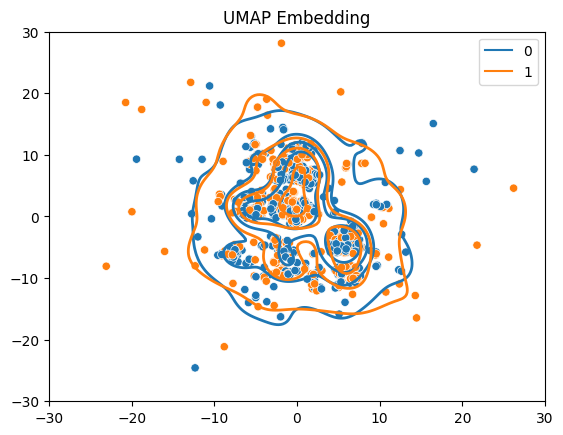

In [20]:
# Ограничим количество точек, чтобы ускорить построение графиков и сделать картинку приятнее
n_points = 1000
ids = np.random.permutation(len(embedding))[:n_points]

ax = sns.scatterplot(x=embedding[ids, 0], y=embedding[ids, 1], hue=labels[ids])

sns.kdeplot(
    x=embedding[ids, 0],
    y=embedding[ids, 1],
    hue=labels[ids],
    levels=5,
    linewidths=2,
    ax=ax,
)

ax.set_title("UMAP Embedding")
ax.set_xlim(-30, 30)
ax.set_ylim(-30, 30)

plt.show()

---

Добавление фич с помощью метода понижения размерности

Так как итоговый скор ухудшился, код закомментирован

In [21]:
# pca = PCA(n_components=0.85)
# pca.fit(x)
# embedding = pca.transform(x)


# for i, component in enumerate(embedding.T):
#     train_df = train_df.with_columns(pl.Series(f"pca_{i}", component))

## Кластеризация (5 баллов)

In [22]:
kmeans = KMeans(n_clusters=8, random_state=SEED)
kmeans.fit(x_train)

KMeans(random_state=666)

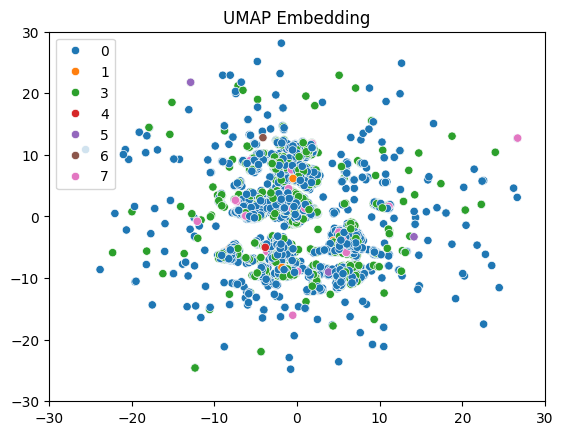

In [23]:
n_points = 5000
ids = np.random.permutation(len(embedding))[:n_points]

cluster = kmeans.predict(x)

ax = sns.scatterplot(
    x=embedding[ids, 0],
    y=embedding[ids, 1],
    hue=cluster[ids],
    palette=sns.color_palette(),
)

ax.set_title("UMAP Embedding")
ax.set_xlim(-30, 30)
ax.set_ylim(-30, 30)

plt.show()

In [24]:
dists = kmeans.transform(x)

for i, dist in enumerate(dists.T):
    train_df = train_df.with_columns(pl.Series(f"kmeans_{i}", dist))


train_df = train_df.with_columns(pl.Series("cluster", cluster))

## Итоговые данные

In [25]:
train_df

user_id,target,click_mean_price,click_std_price,click_min_price,click_max_price,click_sum_price,click_mean_discount_price,click_std_discount_price,click_min_discount_price,click_max_discount_price,click_sum_discount_price,click_mean_category_avg_price,click_std_category_avg_price,click_min_category_avg_price,click_max_category_avg_price,click_sum_category_avg_price,click_mean_category_avg_discount_price,click_std_category_avg_discount_price,click_min_category_avg_discount_price,click_max_category_avg_discount_price,click_sum_category_avg_discount_price,click_count,click_last_days,click_first_days,click_mean_discount_diff,click_std_discount_diff,click_min_discount_diff,click_max_discount_diff,click_most_common_category,click_count_distinct_categories,favorite_mean_price,favorite_std_price,favorite_min_price,favorite_max_price,favorite_sum_price,favorite_mean_discount_price,…,to_cart_std_price,to_cart_min_price,to_cart_max_price,to_cart_sum_price,to_cart_mean_discount_price,to_cart_std_discount_price,to_cart_min_discount_price,to_cart_max_discount_price,to_cart_sum_discount_price,to_cart_mean_category_avg_price,to_cart_std_category_avg_price,to_cart_min_category_avg_price,to_cart_max_category_avg_price,to_cart_sum_category_avg_price,to_cart_mean_category_avg_discount_price,to_cart_std_category_avg_discount_price,to_cart_min_category_avg_discount_price,to_cart_max_category_avg_discount_price,to_cart_sum_category_avg_discount_price,to_cart_count,to_cart_last_days,to_cart_first_days,to_cart_mean_discount_diff,to_cart_std_discount_diff,to_cart_min_discount_diff,to_cart_max_discount_diff,to_cart_most_common_category,to_cart_count_distinct_categories,kmeans_0,kmeans_1,kmeans_2,kmeans_3,kmeans_4,kmeans_5,kmeans_6,kmeans_7,cluster
i32,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,i64,i64,f64,f64,f64,f64,i64,u32,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,i64,i64,f64,f64,f64,f64,i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,i32
4271111,0,320.4,437.180512,85.0,1100.0,1602.0,261.4,337.817702,85.0,865.0,1307.0,535.769952,419.587254,132.030769,1009.592593,2678.849759,347.145309,214.655674,130.646154,596.962963,1735.726547,5,86,86,59.0,101.75952,0.0,235.0,413,5,519.0,null,519.0,519.0,519.0,458.0,…,321.897909,59.0,1100.0,4808.0,237.285714,210.694978,44.0,865.0,3322.0,628.41362,513.636412,163.482877,1643.085324,8797.790684,409.305856,260.754838,154.667808,954.056314,5730.281987,14,86,86,106.142857,152.540465,0.0,447.0,413,9,4.249867,42.790146,3994.542383,6.869726,100.324369,31.311768,61.731594,17.820386,0
96610,0,1133.0,1269.73518,158.0,4099.0,9064.0,1069.25,1297.457596,79.0,4099.0,8554.0,1088.33061,662.27697,291.515152,1682.833333,8706.644882,1058.970308,652.55281,282.416667,1648.611111,8471.762461,8,22,82,63.75,99.806599,0.0,255.0,618,5,null,null,null,null,null,null,…,460.344283,158.0,1927.0,8934.0,627.076923,407.750631,79.0,1563.0,8152.0,1035.799796,534.490609,291.515152,1682.833333,13465.397354,926.615419,559.128289,282.416667,1648.611111,12046.000443,13,22,82,60.153846,114.104372,0.0,364.0,618,8,2.437926,42.454367,3994.531553,5.660001,100.85633,31.532727,61.120756,16.715654,0
8838724,0,257.2,131.077077,99.0,449.0,1286.0,247.0,140.249777,99.0,449.0,1235.0,411.06346,311.134785,117.131148,902.361905,2055.317301,354.011804,279.314038,116.196721,836.82381,1770.059018,5,10,69,10.2,22.807893,0.0,51.0,190,4,null,null,null,null,null,null,…,80.425949,13.0,269.0,1638.0,120.307692,81.340216,12.0,269.0,1564.0,309.779951,235.82805,110.094059,784.341365,4027.139359,247.60613,132.610455,100.831683,482.285141,3218.879692,13,10,20,5.692308,11.190655,0.0,30.0,110,9,3.460236,41.926386,3994.582289,5.372199,101.084627,31.809849,62.055891,17.770803,0
1808121,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,nul

In [26]:
train_df = train_df.to_pandas()

In [27]:
all_features = train_df.columns.tolist()
for feat in ["user_id", "target"]:
    all_features.remove(feat)

categorical_features = [
    "click_most_common_category",
    "favorite_most_common_category",
    "to_cart_most_common_category",
    "order_most_common_category",
    "search_most_common_widget",
    "cluster",
]

numerical_features = train_df.columns.tolist()
for feat in categorical_features + ["user_id", "target"]:
    numerical_features.remove(feat)

In [28]:
train_df[categorical_features] = train_df[categorical_features].astype(str)

In [29]:
train_pool = catboost.Pool(
    train_df.loc[train_ids, all_features],
    train_df.loc[train_ids, "target"],
    cat_features=categorical_features,
)
eval_pool = catboost.Pool(
    train_df.loc[eval_ids, all_features],
    train_df.loc[eval_ids, "target"],
    cat_features=categorical_features,
)

## Обучение CatBoost

In [30]:
model = catboost.CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=10,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=5,
    use_best_model=True,
    early_stopping_rounds=50,
    random_seed=SEED,
    task_type="GPU",
    devices="0",
)

model.fit(train_pool, eval_set=eval_pool)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7797036	best: 0.7797036 (0)	total: 210ms	remaining: 1m 44s
5:	test: 0.7849868	best: 0.7849868 (5)	total: 1.23s	remaining: 1m 40s
10:	test: 0.7866417	best: 0.7866417 (10)	total: 2.24s	remaining: 1m 39s
15:	test: 0.7879178	best: 0.7879178 (15)	total: 3.27s	remaining: 1m 39s
20:	test: 0.7887471	best: 0.7887471 (20)	total: 4.3s	remaining: 1m 38s
25:	test: 0.7895086	best: 0.7895086 (25)	total: 5.31s	remaining: 1m 36s
30:	test: 0.7899917	best: 0.7899917 (30)	total: 6.34s	remaining: 1m 35s
35:	test: 0.7903433	best: 0.7903433 (35)	total: 7.37s	remaining: 1m 34s
40:	test: 0.7906384	best: 0.7906384 (40)	total: 8.41s	remaining: 1m 34s
45:	test: 0.7909954	best: 0.7909954 (45)	total: 9.44s	remaining: 1m 33s
50:	test: 0.7913130	best: 0.7913130 (50)	total: 10.5s	remaining: 1m 32s
55:	test: 0.7914787	best: 0.7914787 (55)	total: 11.6s	remaining: 1m 31s
60:	test: 0.7915830	best: 0.7915830 (60)	total: 12.6s	remaining: 1m 30s
65:	test: 0.7917517	best: 0.7917517 (65)	total: 13.7s	remaining: 1m 3

## Интерпретация модели (5 баллов)

Посмотрим на важность фич и уберем те, которые показали малую значимость

In [31]:
feature_importance = model.get_feature_importance(prettified=True)
feature_importance.head(10)

,Feature Id,Importances
0,order_last_days,7.401656
1,order_first_days,4.867491
2,order_sum_category_avg_price,4.642036
3,search_most_common_widget,4.060656
4,to_cart_last_days,4.022201
5,order_sum_discount_price,3.675808
6,to_cart_most_common_category,3.264773
7,order_most_common_category,2.955779
8,to_cart_sum_discount_price,2.912329
9,search_count,2.897803


In [32]:
feature_importance.tail(30)

,Feature Id,Importances
100,click_std_discount_price,0.156023
101,favorite_min_discount_price,0.150970
102,click_mean_price,0.146837
103,click_sum_price,0.142983
104,favorite_min_category_avg_price,0.141938
105,click_max_discount_price,0.130051
106,kmeans_4,0.126744
107,favorite_count_distinct_categories,0.125843
108,to_cart_mean_category_avg_discount_price,0.119802
109,favorite_last_days,0.119616


In [33]:
all_features_pruned = copy(all_features)
categorical_features_pruned = copy(categorical_features)

features_to_remove = feature_importance[feature_importance["Importances"] < 0.19][
    "Feature Id"
].tolist()

for feat in features_to_remove:
    all_features_pruned.remove(feat)

    if feat in categorical_features:
        categorical_features_pruned.remove(feat)

train_pool = catboost.Pool(
    train_df.loc[train_ids, all_features_pruned],
    train_df.loc[train_ids, "target"],
    cat_features=categorical_features_pruned,
)

eval_pool = catboost.Pool(
    train_df.loc[eval_ids, all_features_pruned],
    train_df.loc[eval_ids, "target"],
    cat_features=categorical_features_pruned,
)


In [34]:
model_pruned = catboost.CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=10,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=5,
    use_best_model=True,
    early_stopping_rounds=50,
    random_seed=SEED,
    task_type="GPU",
    devices="0",
)

model_pruned.fit(train_pool, eval_set=eval_pool)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7801969	best: 0.7801969 (0)	total: 189ms	remaining: 1m 34s
5:	test: 0.7848837	best: 0.7848837 (5)	total: 1.18s	remaining: 1m 37s
10:	test: 0.7869753	best: 0.7869753 (10)	total: 2.21s	remaining: 1m 38s
15:	test: 0.7880156	best: 0.7880156 (15)	total: 3.23s	remaining: 1m 37s
20:	test: 0.7888609	best: 0.7888609 (20)	total: 4.3s	remaining: 1m 38s
25:	test: 0.7895103	best: 0.7895103 (25)	total: 5.32s	remaining: 1m 37s
30:	test: 0.7899934	best: 0.7899934 (30)	total: 6.35s	remaining: 1m 36s
35:	test: 0.7904767	best: 0.7904767 (35)	total: 7.39s	remaining: 1m 35s
40:	test: 0.7908216	best: 0.7908216 (40)	total: 8.4s	remaining: 1m 34s
45:	test: 0.7910442	best: 0.7910442 (45)	total: 9.44s	remaining: 1m 33s
50:	test: 0.7912956	best: 0.7912956 (50)	total: 10.4s	remaining: 1m 31s
55:	test: 0.7914817	best: 0.7914817 (55)	total: 11.5s	remaining: 1m 31s
60:	test: 0.7916193	best: 0.7916193 (60)	total: 12.5s	remaining: 1m 29s
65:	test: 0.7917909	best: 0.7917909 (65)	total: 13.5s	remaining: 1m 29

Исключение фич, показавших низкую значимость увеличило скор, так что предсказания будем делать с помощью `model_pruned`

## Предсказание на тестовых данных

In [35]:
test_users = test_users.with_columns(
    pl.Series("user_id", test_users["user_id"].cast(pl.Int32))
)

In [36]:
test_df = get_aggregation_features(test_users, control_end_date, history_depth_months=8)

In [37]:
x_test = test_df.drop("user_id").to_numpy()
np.nan_to_num(x_test, copy=False, nan=0)
x_test = (x_test - means) / stds

In [38]:
dists = kmeans.transform(x_test)

for i, dist in enumerate(dists.T):
    test_df = test_df.with_columns(pl.Series(f"kmeans_{i}", dist))

cluster = kmeans.predict(x_test)
test_df = test_df.with_columns(pl.Series("cluster", cluster))

In [39]:
test_df = test_df.to_pandas()
test_df[categorical_features] = test_df[categorical_features].astype(str)

In [40]:
test_pool = catboost.Pool(
    test_df.loc[:, all_features_pruned],
    cat_features=categorical_features_pruned,
)

In [41]:
preds = model_pruned.predict_proba(test_pool)[:, 1]

In [42]:
submission = test_users.select("user_id").with_columns(pl.Series("predict", preds)).to_pandas()
submission.to_csv("submission.csv", index=False)